In [2]:
# Task 2 - Data Cleaning & Exploratory Data Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the dataset

df = pd.read_csv("sales_data.csv.txt")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
# Display the first 5 rows

df.head()

,Order_ID,Product,Category,Quantity,Price,Region,Customer_Rating
0,1001,Laptop,Electronics,2,55000,South,4.5
1,1002,Mouse,Electronics,5,800,North,4.0
2,1003,Keyboard,Electronics,3,1500,East,4.2
3,1004,Chair,Furniture,2,4500,West,3.8
4,1005,Table,Furniture,1,7000,South,4.5


In [6]:
# Check the shape of the dataset

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 21
Number of columns: 7


In [7]:
# Check data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         21 non-null     int64  
 1   Product          21 non-null     object 
 2   Category         21 non-null     object 
 3   Quantity         21 non-null     int64  
 4   Price            21 non-null     int64  
 5   Region           21 non-null     object 
 6   Customer_Rating  20 non-null     float64
dtypes: float64(1), int64(3), object(3)
memory usage: 1.3+ KB


In [8]:
# Check for missing values

df.isnull().sum()

Order_ID           0
Product            0
Category           0
Quantity           0
Price              0
Region             0
Customer_Rating    1
dtype: int64

In [9]:
# Handle missing values

average_rating = df["Customer_Rating"].mean()

df["Customer_Rating"] = df["Customer_Rating"].fillna(average_rating)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Order_ID           0
Product            0
Category           0
Quantity           0
Price              0
Region             0
Customer_Rating    0
dtype: int64


In [10]:
# Check duplicate rows

print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 1


In [11]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Duplicates removed.")
print("Number of rows after removing duplicates:", len(df))

Duplicates removed.
Number of rows after removing duplicates: 20


In [12]:
# Detect outliers using IQR

numerical_columns = ["Quantity", "Price", "Customer_Rating"]

for column in numerical_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower_limit) |
        (df[column] > upper_limit)
    ]

    print(f"{column}: {len(outliers)} outlier(s)")

Quantity: 3 outlier(s)
Price: 2 outlier(s)
Customer_Rating: 0 outlier(s)


In [13]:
# Statistical summary of numerical columns

df.describe()

,Order_ID,Quantity,Price,Customer_Rating
count,20.00000,20.000000,20.000000,20.000000
mean,1010.50000,4.700000,8354.500000,4.168000
std,5.91608,5.027294,13686.161076,0.247208
min,1001.00000,1.000000,50.000000,3.700000
25%,1005.75000,2.000000,550.000000,4.000000
50%,1010.50000,3.000000,2150.000000,4.130000
75%,1015.25000,5.000000,9750.000000,4.325000
max,1020.00000,20.000000,55000.000000,4.600000


In [14]:
# Number of products in each category

df["Category"].value_counts()

Category
Electronics    10
Stationery      5
Furniture       4
Accessories     1
Name: count, dtype: int64

In [15]:
# Number of sales records by region

df["Region"].value_counts()

Region
South    5
North    5
East     5
West     5
Name: count, dtype: int64

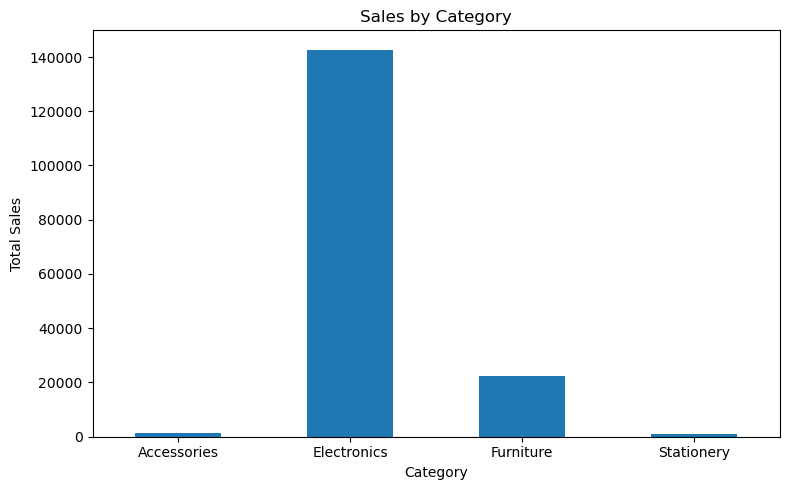

In [16]:
# Sales by Category

category_sales = df.groupby("Category")["Price"].sum()

category_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

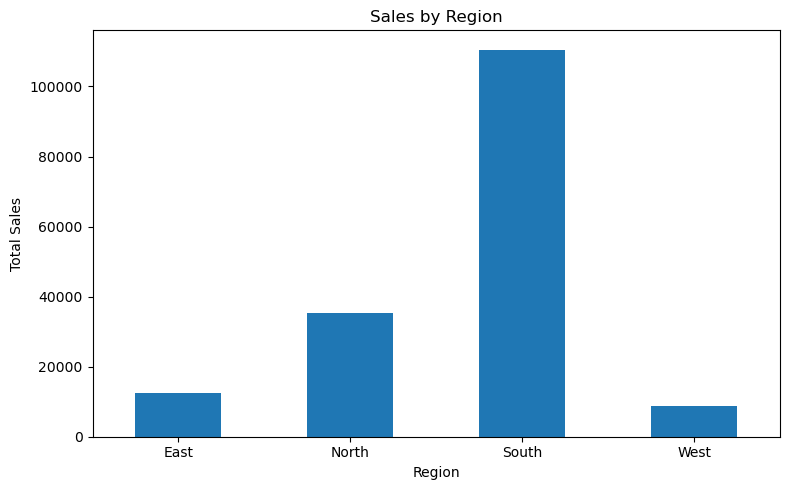

In [17]:
# Sales by Region

region_sales = df.groupby("Region")["Price"].sum()

region_sales.plot(kind="bar", figsize=(8, 5))

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

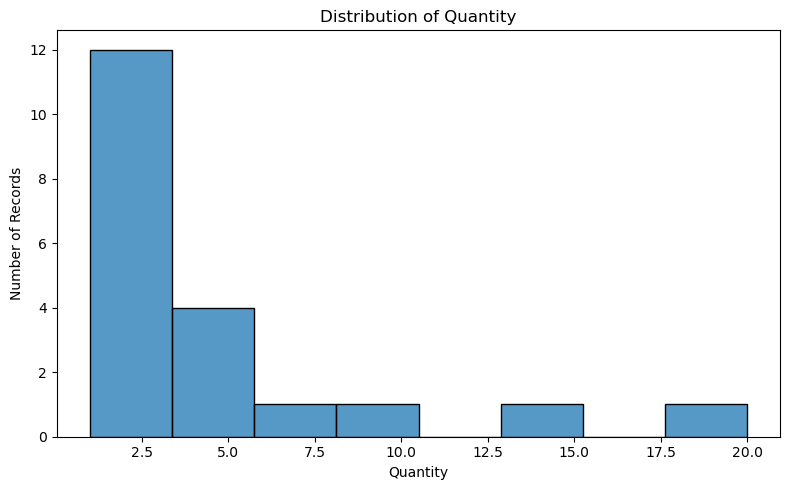

In [18]:
# Distribution of Quantity

plt.figure(figsize=(8, 5))

sns.histplot(df["Quantity"], bins=8)

plt.title("Distribution of Quantity")
plt.xlabel("Quantity")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

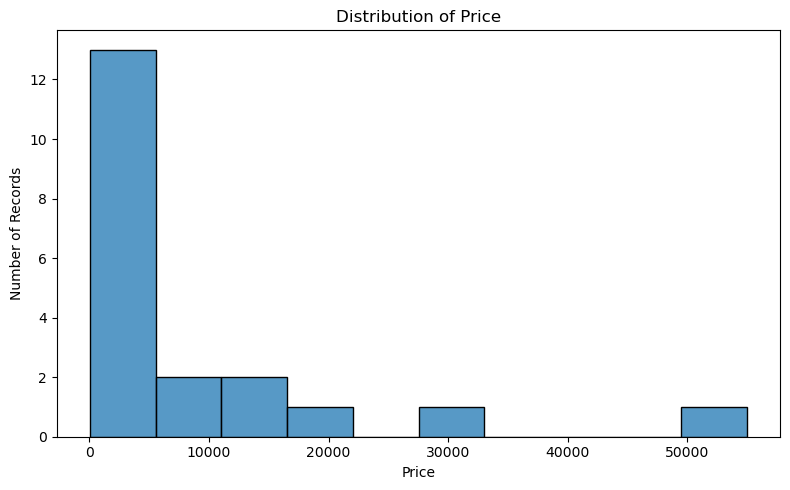

In [19]:
# Distribution of Price

plt.figure(figsize=(8, 5))

sns.histplot(df["Price"], bins=10)

plt.title("Distribution of Price")
plt.xlabel("Price")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

In [20]:
# Correlation Analysis

correlation = df[["Quantity", "Price", "Customer_Rating"]].corr()

print("Correlation Matrix:")
display(correlation)

Correlation Matrix:


,Quantity,Price,Customer_Rating
Quantity,1.000000,-0.372439,0.005421
Price,-0.372439,1.000000,0.394456
Customer_Rating,0.005421,0.394456,1.000000


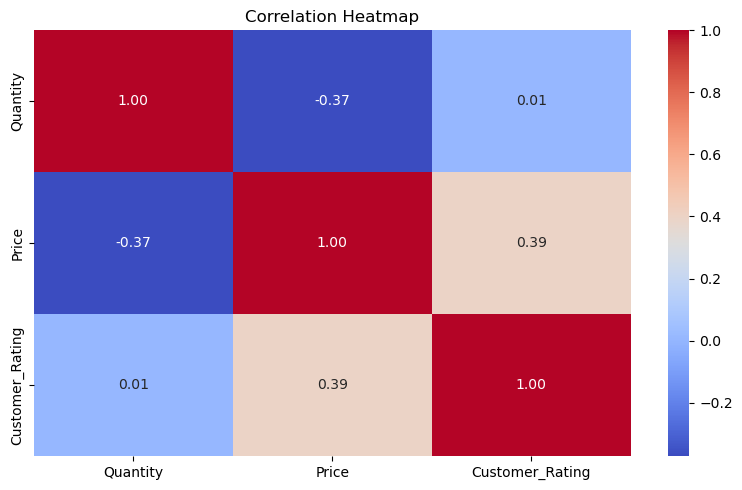

In [21]:
# Correlation Heatmap

plt.figure(figsize=(8, 5))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [22]:
# Product-wise sales analysis

product_sales = df.groupby("Product")["Price"].sum().sort_values(ascending=False)

print("Top Products by Sales:")
display(product_sales.head(10))

Top Products by Sales:


Product
Laptop        55000
Phone         30000
Tablet        22000
Printer       15000
Monitor       12000
Desk           9000
Table          7000
Chair          4500
Webcam         3500
Headphones     2500
Name: Price, dtype: int64

# Key Findings

## Data Cleaning

- The dataset initially contained 21 records.
- One missing value was identified in the Customer_Rating column.
- The missing rating was replaced using the mean customer rating.
- One duplicate record was identified and removed.
- The cleaned dataset contains 20 records.

## Exploratory Data Analysis

- Sales were analyzed across different product categories.
- Regional sales distribution was examined.
- Quantity and price distributions were visualized.
- Correlation analysis was performed between quantity, price, and customer rating.
- Product-wise sales were analyzed to identify high-value products.

## Conclusion

The dataset was successfully cleaned and analyzed using Python, Pandas, NumPy, Matplotlib, and Seaborn. The EDA process helped identify patterns, distributions, and relationships within the sales data.